# Tracking Political Change with EMbeddings of Parliamentary Speeches
________________________________________________________________________________

# Topic Analysis

We build the speech topics from the **fine-tuned embeddings** (BERTopic on the Jina vectors, `min_topic_size = 150`) - i.e. speeches are clustered by meaning, not by word overlap.

We keep two assignments: the raw one (BERTopic leaves the vague speeches as `-1`) and a reduced one where every leftover speech goes to its nearest topic. At the end we save both, together with the topic names.

In [ ]:
!pip install bertopic nltk

In [ ]:
# unicodedata: needed to normalise the German umlauts consistently (see cell below)
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bertopic import BERTopic
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer

import nltk
nltk.download("stopwords", quiet=True)   # German stopword list, used to clean the topic labels
from nltk.corpus import stopwords

## 1. Load the data

In [ ]:
# full fine-tuned embedding dataset, already containing the speech texts
df = pd.read_parquet("jina_v3_contrastive_full.parquet")
df = df[df["speechContent"].notna() & (df["speechContent"].str.strip() != "")].reset_index(drop=True)

# NFC composes "u + combining diaeresis" into a single "ü", so the same word is not counted twice
docs = [unicodedata.normalize("NFC", t) for t in df["speechContent"].tolist()]
# the vectors from notebook 02-02; BERTopic gets them ready-made instead of embedding the texts itself
embeddings = np.array(df["embedding"].tolist(), dtype="float32")

print(f"{len(df):,} speeches")
print("columns:", list(df.columns))
print("umlaut check:", repr(docs[0][:100]))

82,447 speeches
columns: ['id', 'speechContent', 'politicianId', 'politicianName', 'firstName', 'lastName', 'positionShort', 'factionId', 'party', 'date', 'year', 'year_month', 'n_tokens', 'used_in_finetune', 'used_in_party_probe_val', 'used_in_party_probe_test', 'used_finetuned_weights', 'embedding']
umlaut check: 'Meine werten Kolleginnen und Kollegen! Liebe Kolleginnen und Kollegen von der Union, Sie müssen unte'


**82,447 speeches** loaded straight from the embedding file (text and vector live in the same table). The umlaut check prints real ü / ä / ö, so the German text survived the import intact.

## Shared text settings (umlaut-safe)

In [ ]:
# labels are built from word counts, so the vocabulary needs its own stopword handling:
# NLTK's German list alone leaves the plenary boilerplate ("Herr Präsident", "vielen Dank") in
def strip_accents(w):
    return unicodedata.normalize("NFKD", w).encode("ascii", "ignore").decode("ascii")

plenary = [
    "herr", "frau", "damen", "herren", "kollege", "kollegin", "kolleginnen",
    "kollegen", "präsident", "präsidentin", "dank", "danke", "vielen", "sehr",
    "geehrter", "geehrte", "liebe", "meine", "schon", "mehr", "gibt", "heute",
    "gesagt", "gesetzentwurf", "antrag", "deutschland", "bundesregierung",
    "können", "müssen", "worden", "ganz", "wäre", "gerne", "sagen", "geht", "immer",
]
filler = ["ja", "dafür", "natürlich", "tun", "gut", "wirklich", "wissen", "brauchen",
          "thema", "glaube", "wichtig", "deswegen", "punkt", "möchte", "bereits",
          "deshalb", "dabei", "sowie", "mal", "endlich", "eigentlich", "sage",
          "wer", "reden", "darüber", "nehmen", "hätte", "hätten", "sei", "herrn"]
# both spellings of every stopword ("für" and "fur"), so a word is filtered whichever way it is written
base = set(stopwords.words("german")) | set(plenary) | set(filler)
german_stop = sorted(base | {strip_accents(w) for w in base})

# custom token pattern: keeps umlauts and hyphenated compounds, drops numbers and single letters
german_token = r"(?u)\b[A-Za-zÄÖÜäöüß][A-Za-zÄÖÜäöüß-]+\b"

## 2. Embedding-based topics (BERTopic, min size 150).

In [ ]:
# the vectorizer is only used to NAME the clusters afterwards, not to build them
vectorizer = CountVectorizer(stop_words=german_stop, strip_accents=None,
                             token_pattern=german_token, min_df=10, ngram_range=(1, 2))

# UMAP reduces the 1024-dim embeddings before clustering; random_state fixes the result
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                  metric="cosine", init="random", random_state=42)

topic_model = BERTopic(
    embedding_model=None,            # None = do not embed the texts, use the vectors passed below
    umap_model=umap_model,
    vectorizer_model=vectorizer,
    min_topic_size=150,              # a cluster needs 150 speeches to count as a topic (keeps them balanced)
    calculate_probabilities=False,
    verbose=True,
)

# [0] takes the topic label per speech; [1] would be the probabilities, which we switched off
topics_raw = topic_model.fit_transform(docs, embeddings=embeddings)[0]

2026-08-17 08:40:31,360 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-17 08:42:32,903 - BERTopic - Dimensionality - Completed ✓
2026-08-17 08:42:32,907 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-17 08:42:49,128 - BERTopic - Cluster - Completed ✓
2026-08-17 08:42:49,162 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-17 08:44:12,010 - BERTopic - Representation - Completed ✓


In [ ]:
df["topic_emb_raw"] = topics_raw
# path B: give every -1 speech the topic of its nearest cluster in embedding space
# (threshold=0.0 means no minimum similarity, so nothing stays unassigned)
topics_full = topic_model.reduce_outliers(docs, topics_raw, strategy="embeddings",
                                          embeddings=embeddings, threshold=0.0)
df["topic_emb_full"] = topics_full

n_topics = len([t for t in set(topics_raw) if t != -1])   # -1 is the outlier bucket, not a topic
print(f"{n_topics} embedding topics")
print(f"path A unassigned: {(df['topic_emb_raw']  == -1).mean():.0%}")
print(f"path B unassigned: {(df['topic_emb_full'] == -1).mean():.0%}")

72 embedding topics
path A unassigned: 24%
path B unassigned: 0%


BERTopic found **72 topics** from the embeddings. **Path A** leaves **24%** of speeches unassigned (`-1`) — the vague / mixed ones HDBSCAN won't force into a cluster. **Path B** reassigns those to their nearest topic, so every speech gets a label. At `min_topic_size=150` the topics stay balanced — no single dominating topic.

### Umlaut-correct topic labels

BERTopic's own labels strip the umlauts, so we build labels ourselves from a plain CountVectorizer (keeps umlauts) using an over-representation score.

In [ ]:
label_vec = CountVectorizer(stop_words=german_stop, strip_accents=None,
                            token_pattern=german_token, min_df=20)
X_label = label_vec.fit_transform(docs)
vocab_label = np.array(label_vec.get_feature_names_out())
overall = np.asarray(X_label.sum(axis=0)).ravel() + 1   # +1 avoids dividing by zero below

def label_topics(topic_col, n=3):
    labels, arr = {}, df[topic_col].to_numpy()
    for t in sorted(set(arr)):
        if t == -1:
            continue
        # word frequencies inside this topic, compared with their frequency in the whole corpus
        cnt = np.asarray(X_label[arr == t].sum(axis=0)).ravel()
        lift = (cnt / max(cnt.sum(), 1)) / (overall / overall.sum())
        lift[cnt < 20] = 0   # a word seen fewer than 20 times can have huge lift by accident
        labels[t] = f"{t}: " + "/".join(vocab_label[lift.argsort()[::-1][:n]])   # top n words by lift
    return labels

# labels come from path A only: the same topic ids are used for both paths, so one set of names fits both
emb_labels = label_topics("topic_emb_raw")

counts = df["topic_emb_raw"].value_counts()
overview = (pd.DataFrame([{"topic": t, "count": int(counts.get(t, 0)), "label": lab}
                          for t, lab in emb_labels.items()])
            .sort_values("count", ascending=False).reset_index(drop=True))
overview

,topic,count,label
0,0,5643,0: oecd-musterabkommen/regelgrenze/mittelstand...
1,1,4371,1: megahertz/polizeibeauftragten/netzneutralität
2,2,4090,2: tierhalter/imker/ställe
3,3,3082,3: arzneimittelausgaben/rsa/psg
4,4,3020,4: bafög-bericht/bologna-reform/studienfinanzi...
...,...,...,...
67,67,185,67: atalanta/piratenangriffe/piraterie
68,68,167,68: transplantationsbeauftragten/organspendeau...
69,69,165,69: substitutionsbehandlung/cannabiskonsumente...
70,70,162,70: cybergrooming/kinderpornographie/sexuellem


In [ ]:
biggest_category_count = overview.iloc[0]['count']
total_speeches = len(df)
percentage = (biggest_category_count / total_speeches) * 100

print(f"The biggest speech category accounts for {percentage:.2f}% of all speeches.")

The biggest speech category accounts for 6.84% of all speeches.


The **72 topics, largest first**. The biggest is ~6.84% of all speeches.
Labels are each topic's most *over-represented* words, umlauts intact; the themes are specific and readable (energy, Greece/Grexit, migration, childcare, …).

## 3. Topics over time

Share of each year's speeches per topic. With this many topics one plot is unreadable, so we draw them in batches of ~10 (biggest topics first), once per path.

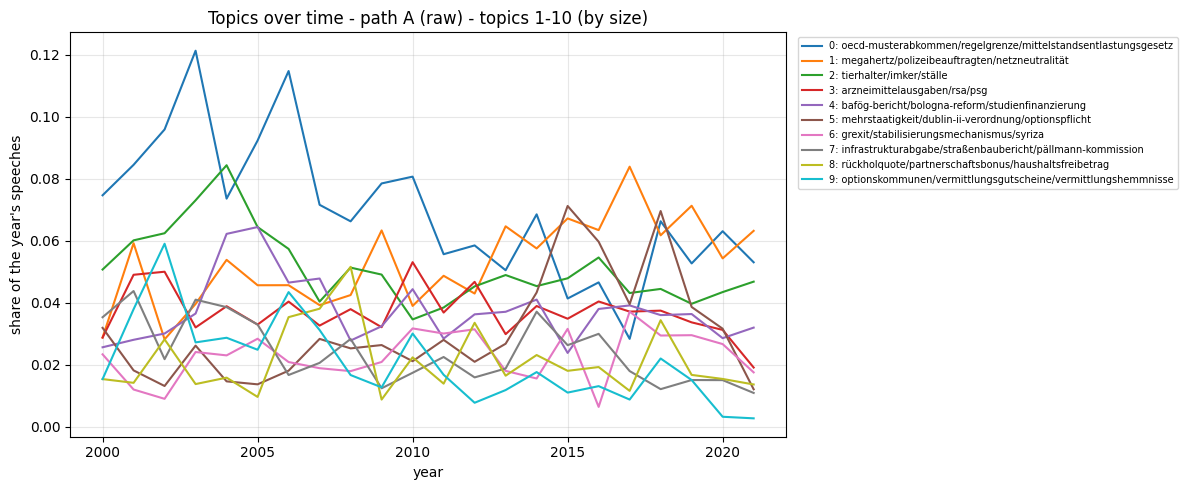

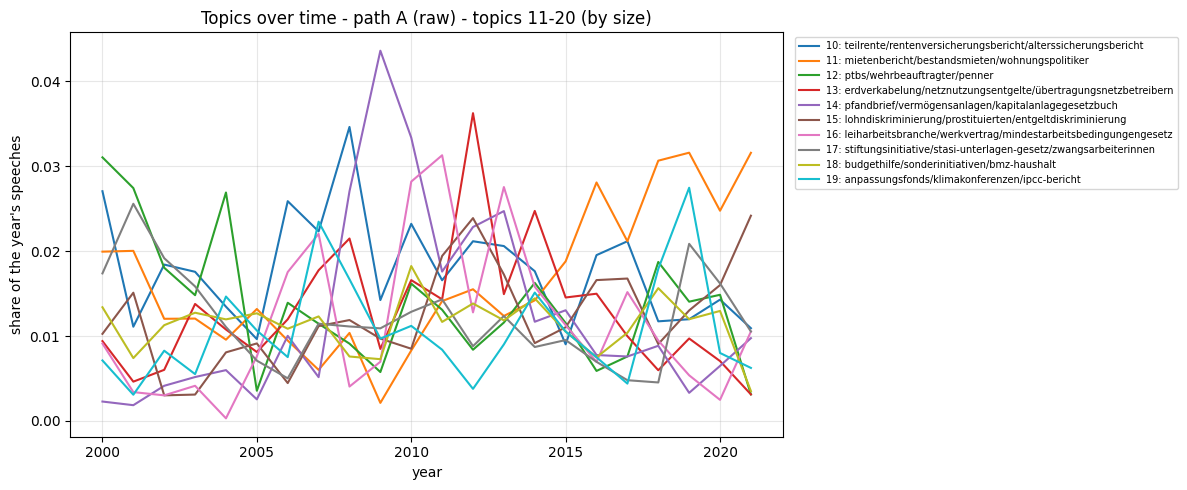

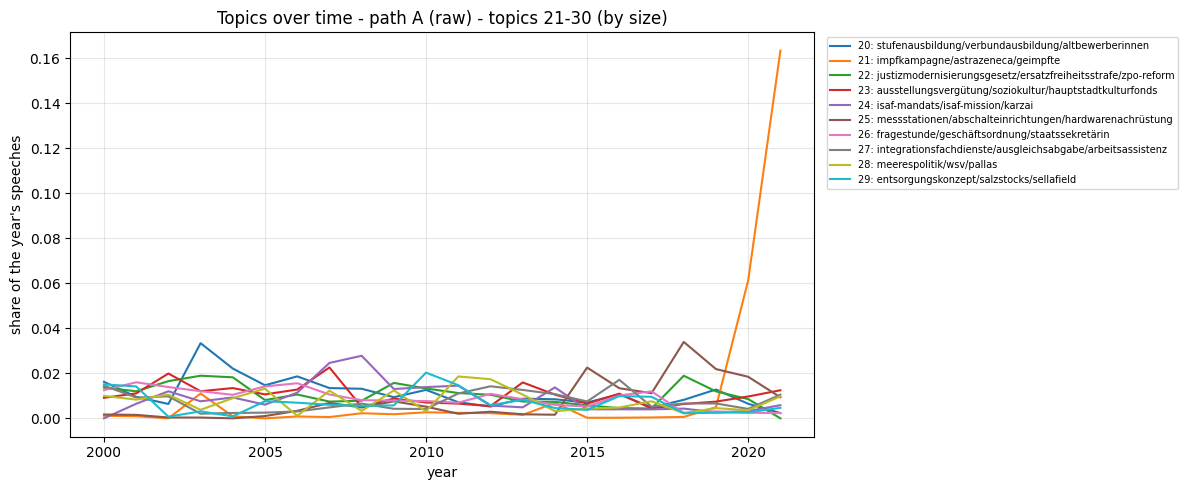

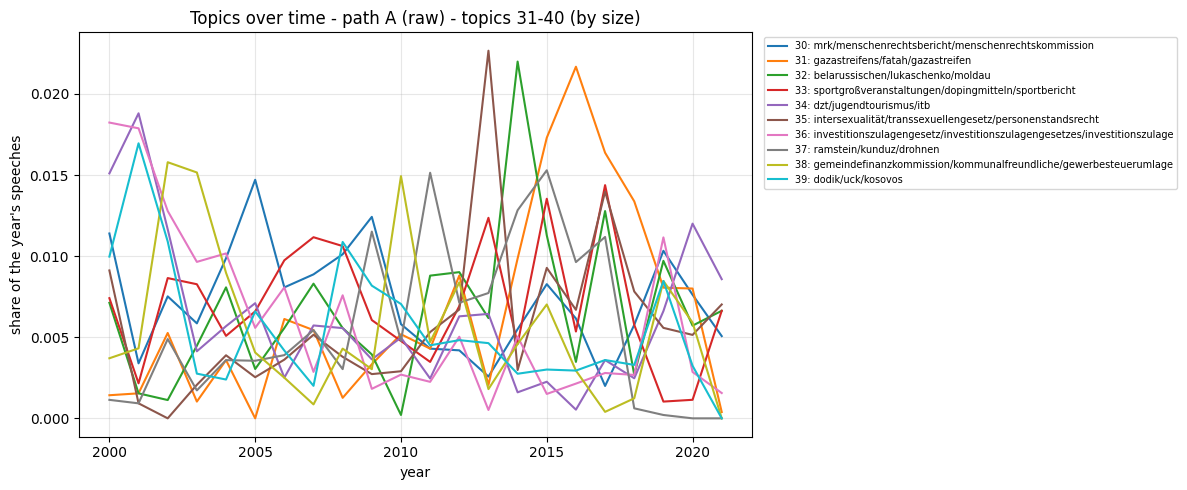

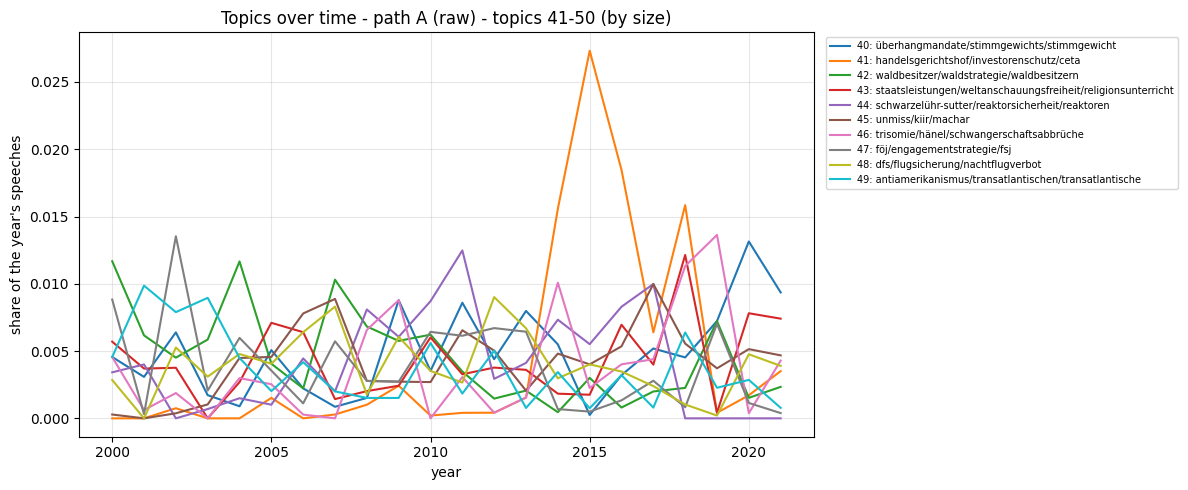

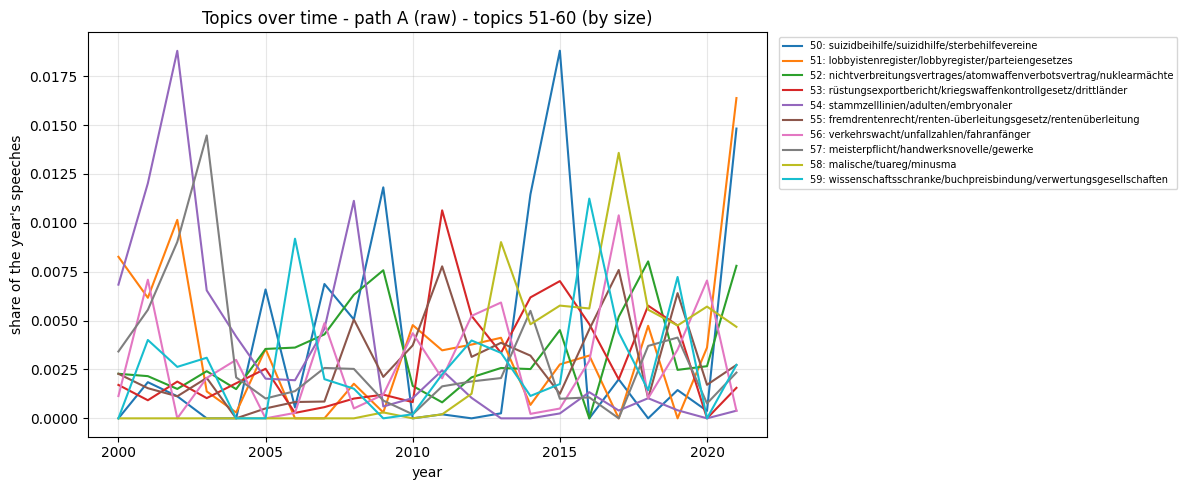

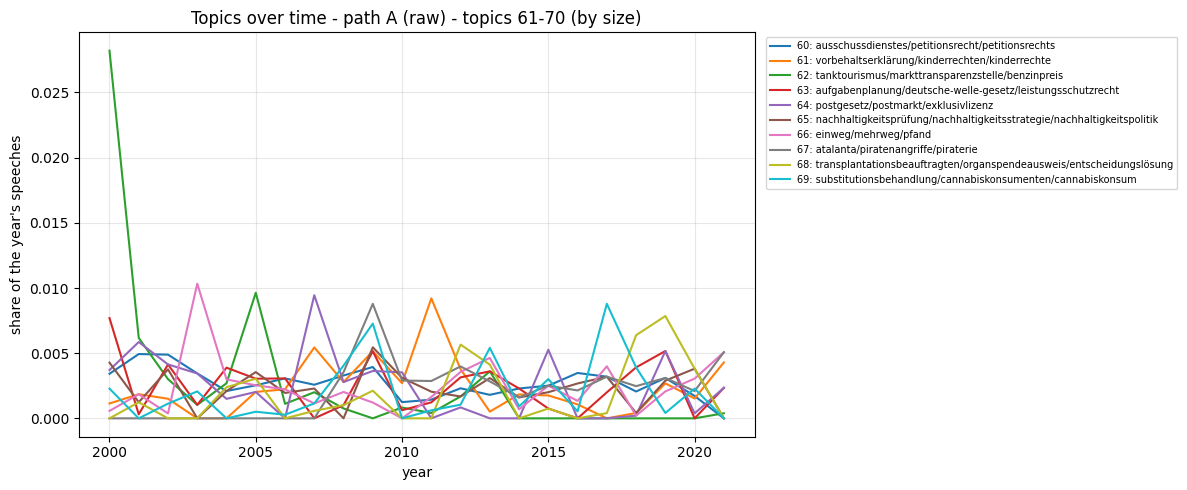

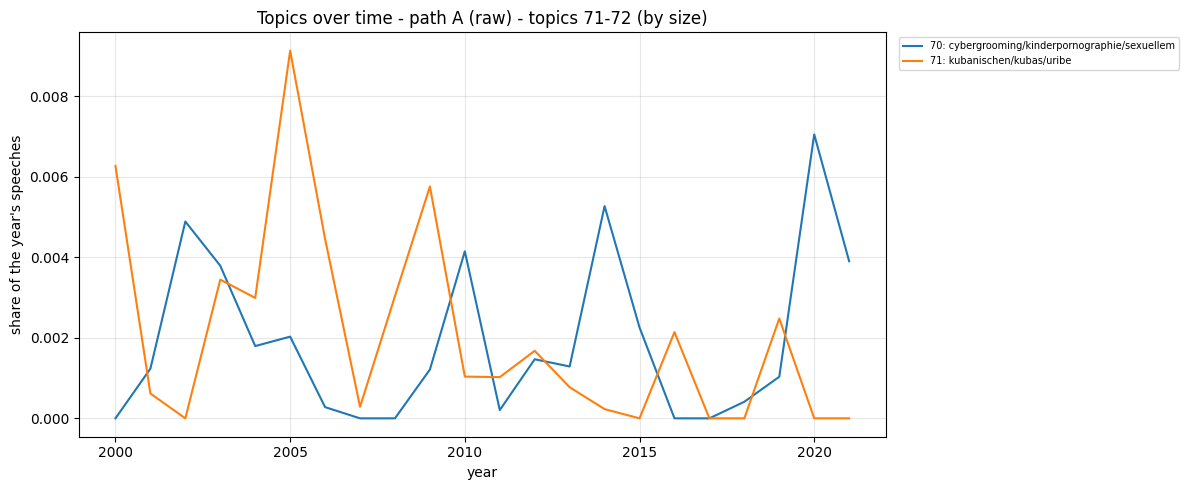

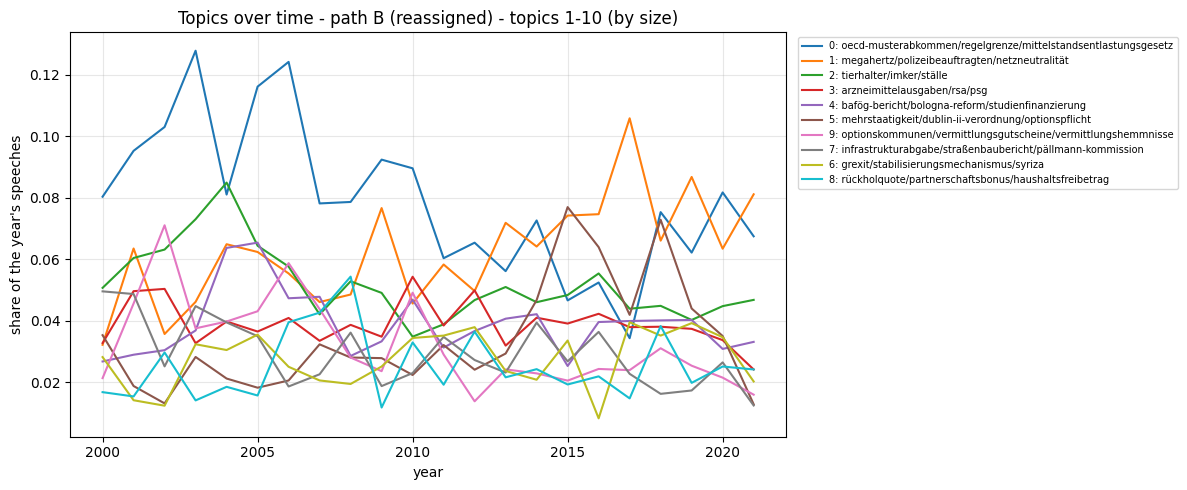

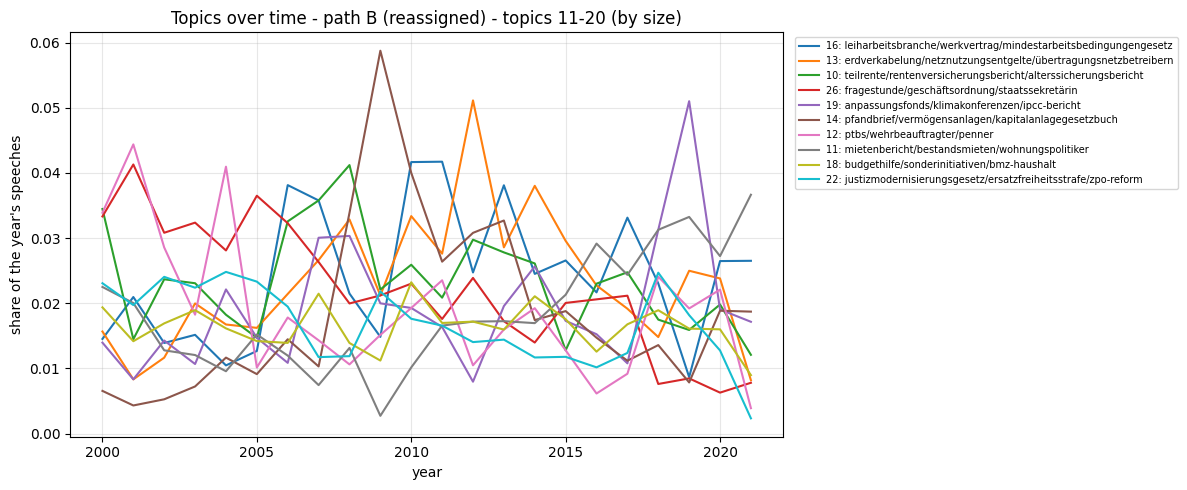

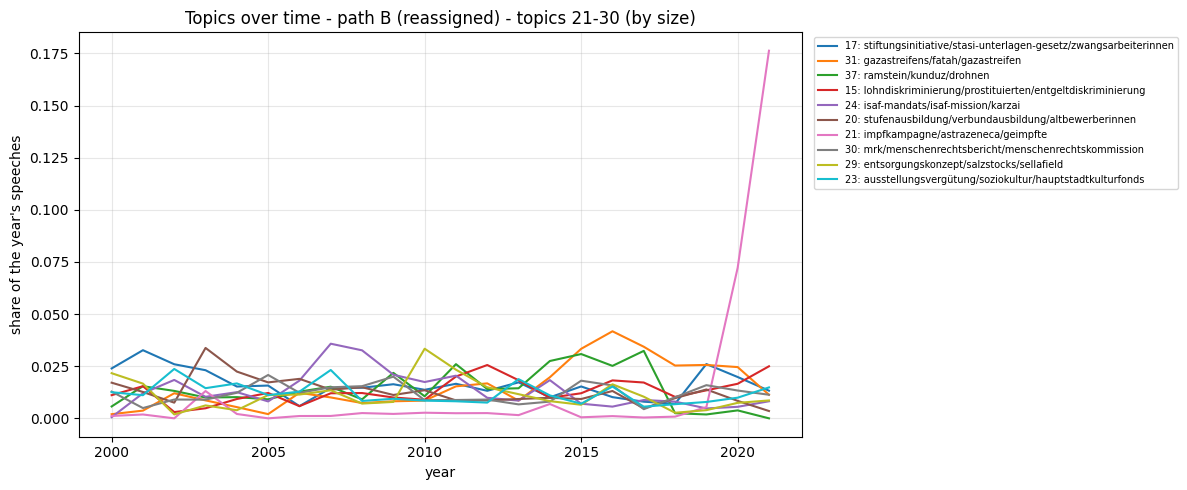

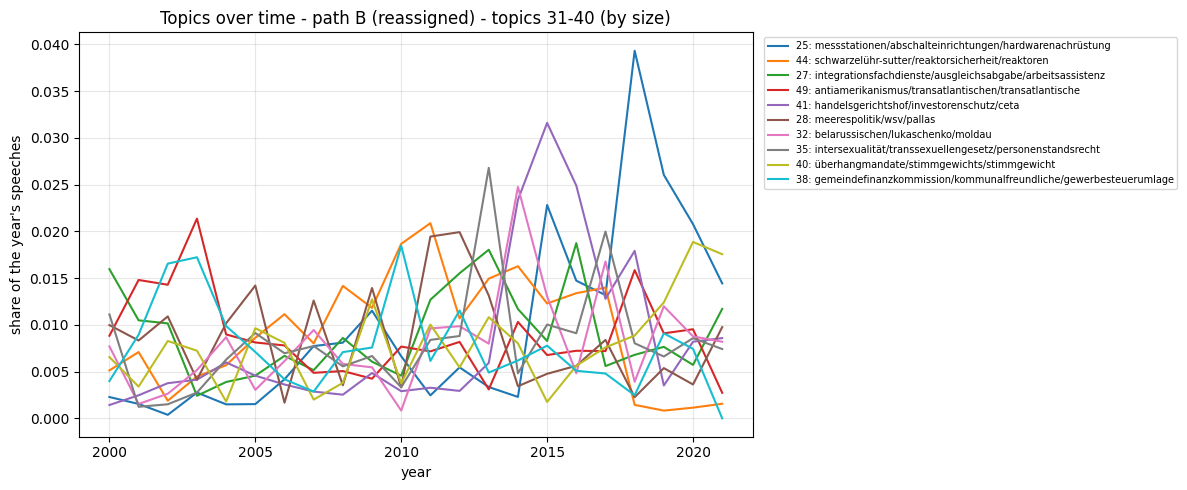

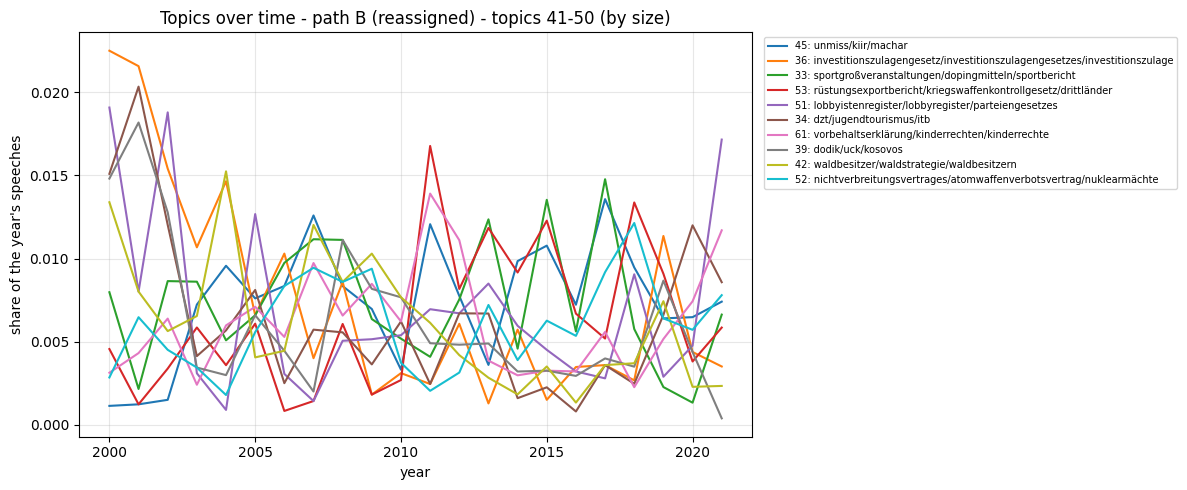

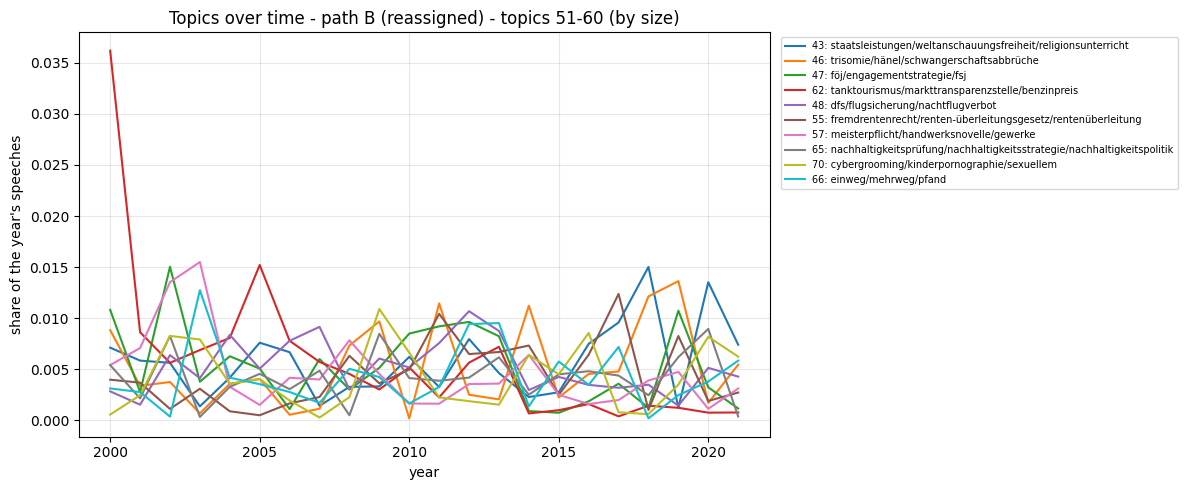

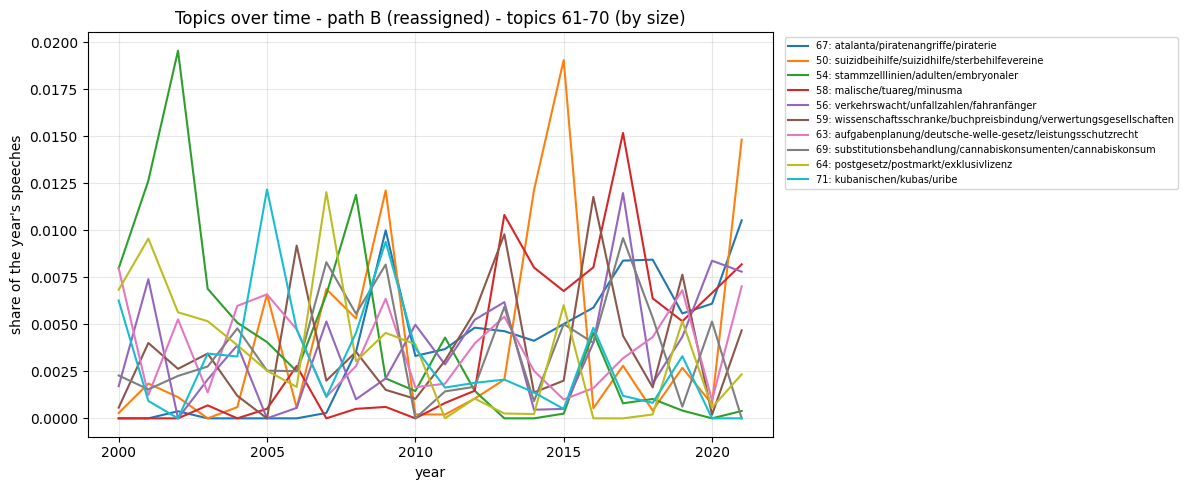

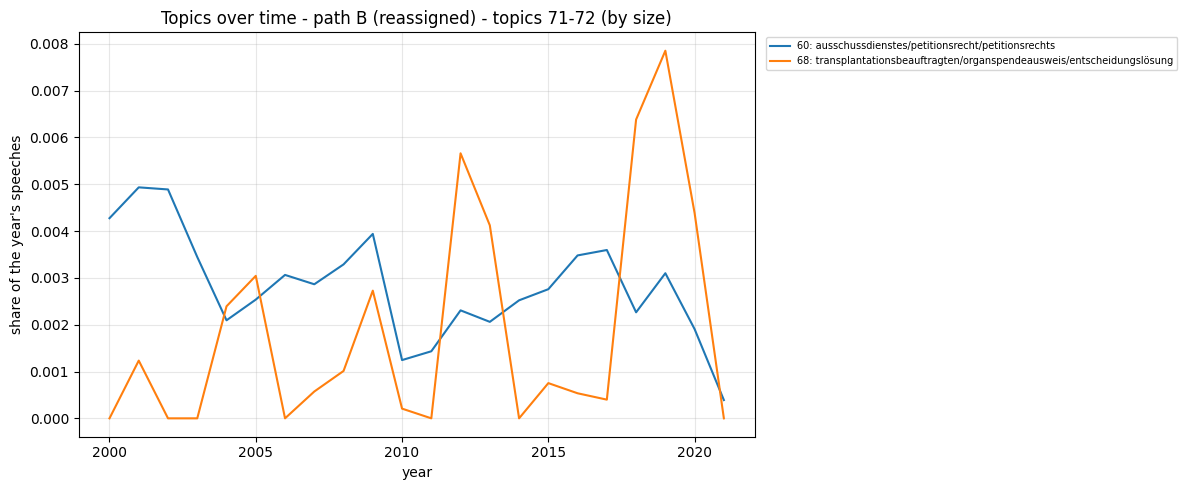

In [ ]:
def topics_over_time(topic_col, title, per_plot=10):
    # normalize="index" -> each year sums to 1, so a topic's line is its share of that year,
    # not the raw count (parliament speaks more in some years than others)
    share = pd.crosstab(df["year"], df[topic_col], normalize="index")
    order = df.loc[df[topic_col] != -1, topic_col].value_counts().index.tolist()   # biggest first
    for i in range(0, len(order), per_plot):
        chunk = order[i:i + per_plot]
        ax = share[chunk].plot(figsize=(12, 5))
        ax.set_xlabel("year"); ax.set_ylabel("share of the year's speeches")
        ax.set_title(f"{title} - topics {i + 1}-{i + len(chunk)} (by size)")
        ax.legend([emb_labels[t] for t in chunk], bbox_to_anchor=(1.01, 1),
                  loc="upper left", fontsize=7)
        ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

topics_over_time("topic_emb_raw",  "Topics over time - path A (raw)")
topics_over_time("topic_emb_full", "Topics over time - path B (reassigned)")

Each line is a topic's **share of that year's speeches**. Event-driven topics rise and fall on cue (the pandemic topic from 2020, migration around 2015). Path A and Path B tell the same story; Path B's shares sit slightly higher because the reassigned 23% are spread back across the topics.

We could use this graphes also for event analysis.
  -> within-topic movement of parties

## 4. Topic share per party

Share of each party's speeches per topic (row-normalised by party), all topics, once per path.

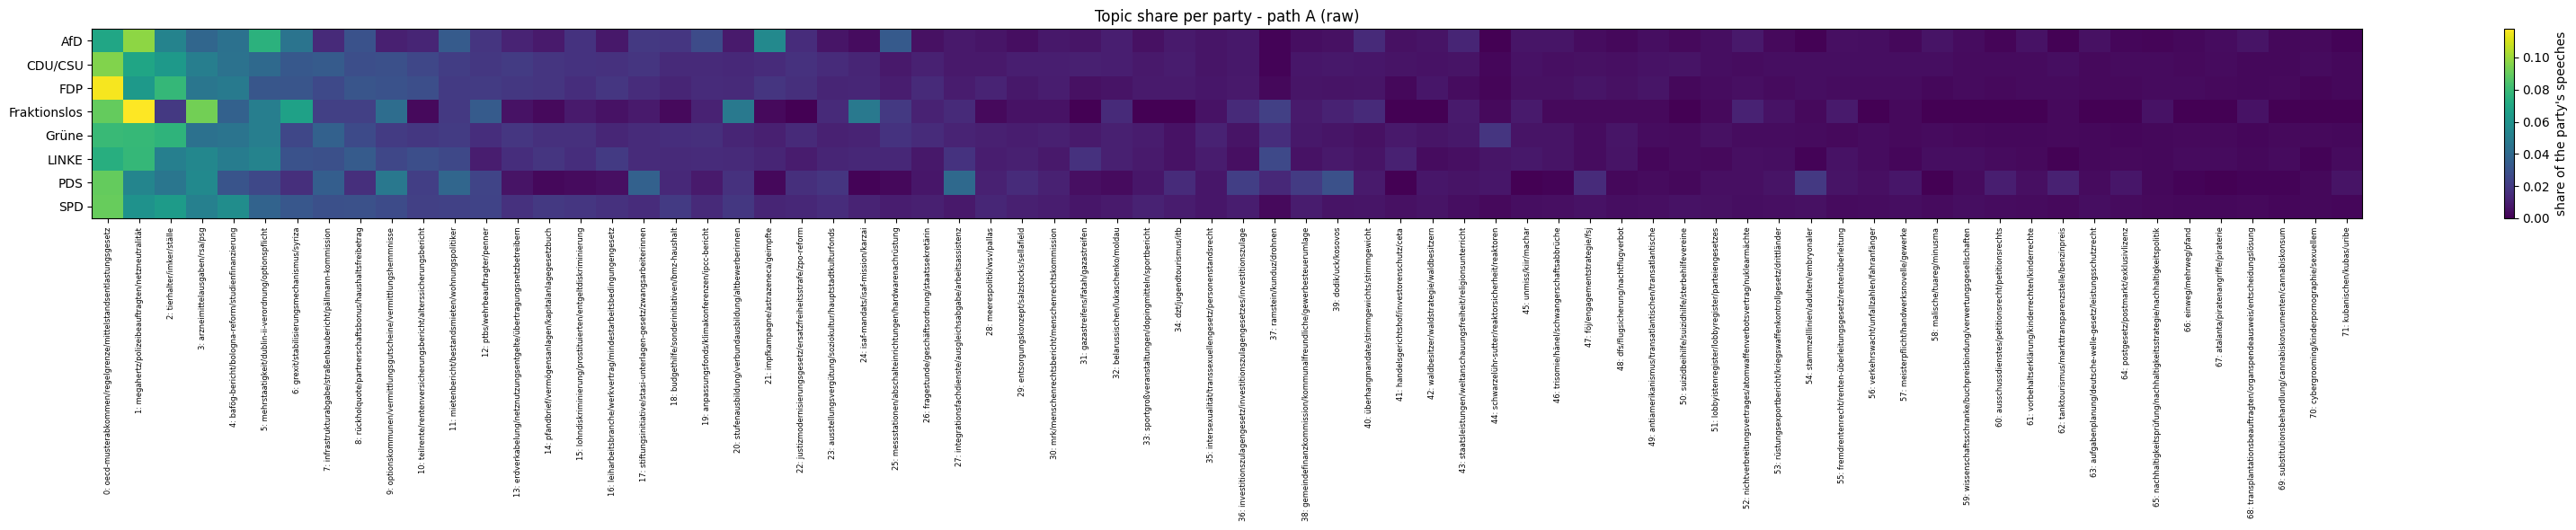

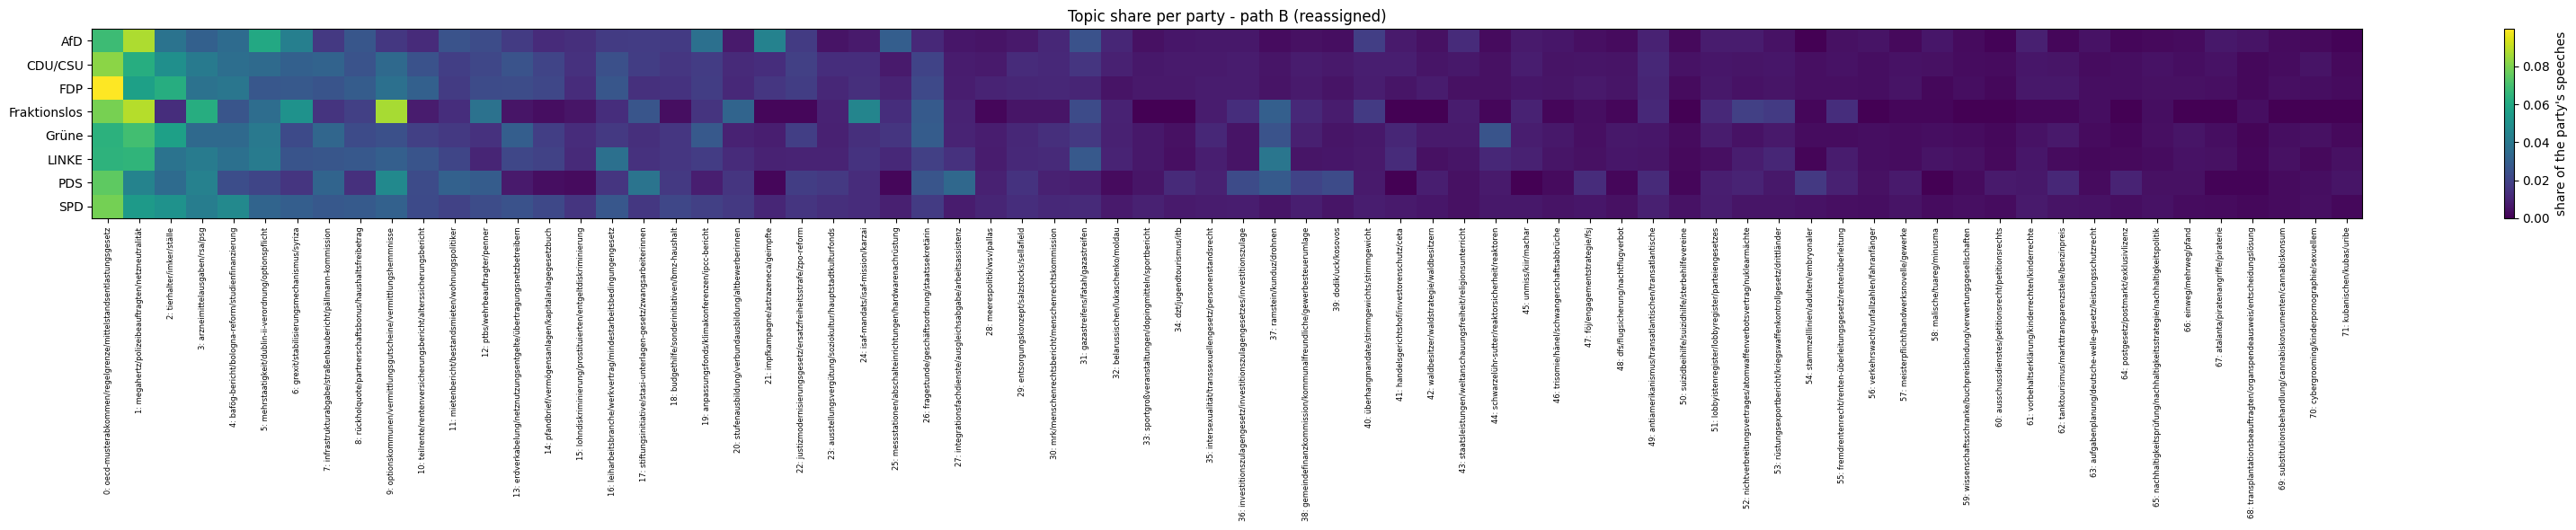

In [ ]:
def topic_share_per_party(topic_col, title):
    d = df[df[topic_col] != -1]        # drop the outlier bucket, it is not a theme
    topics = sorted(d[topic_col].unique())
    # row-normalised: each party sums to 1, so parties with very different speech counts stay comparable
    prof = pd.crosstab(d["party"], d[topic_col], normalize="index")[topics]

    fig, ax = plt.subplots(figsize=(0.4 * len(topics) + 4, 6))
    im = ax.imshow(prof.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(topics)))
    ax.set_xticklabels([emb_labels[t] for t in topics], rotation=90, fontsize=6)
    ax.set_yticks(range(len(prof.index))); ax.set_yticklabels(prof.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="share of the party's speeches")
    plt.tight_layout(); plt.show()

topic_share_per_party("topic_emb_raw",  "Topic share per party - path A (raw)")
topic_share_per_party("topic_emb_full", "Topic share per party - path B (reassigned)")

Each **row is a party's topic profile** — the share of *its* speeches on each topic (normalised per party, so parties are comparable despite very different speech counts). Bright cells show where a party over-indexes on a theme; flat columns are shared parliamentary business.

Would be more readable if split in severak graphes with less topics/focus on most important topics, but not relevant fir report anyways

## 5. Embedding clusters in 2D

In [ ]:
import umap
N = 20000                                  # plotting all 82k points is slow and unreadable, so we sample
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=min(N, len(df)), replace=False)
# a second, separate UMAP: 2 components for the picture (the clustering above used 5)
xy = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine",
               init="random", random_state=42).fit_transform(embeddings[idx])

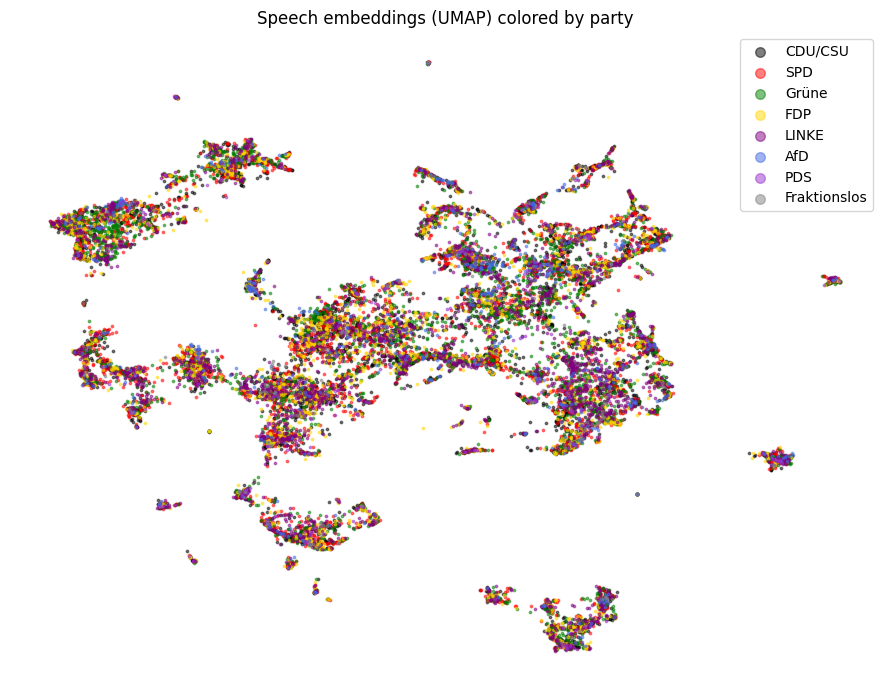

In [ ]:
party_sample = df["party"].to_numpy()[idx]
party_colors = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "DIE LINKE.": "purple", "AfD": "royalblue",
                "PDS": "darkorchid", "Fraktionslos": "grey"}

fig, ax = plt.subplots(figsize=(9, 7))
for p, c in party_colors.items():
    m = party_sample == p
    if m.any():
        ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=0.5, color=c, label=p)
ax.legend(markerscale=4); ax.axis("off")
ax.set_title("Speech embeddings (UMAP) colored by party")
plt.tight_layout(); plt.show()

Speech embeddings in 2D, coloured by **party**. The colours are largely **mixed** — speeches barely separate by party, because what a speech is *about* dominates its embedding far more than who gave it. (This is also why the ideological signal is weak.)

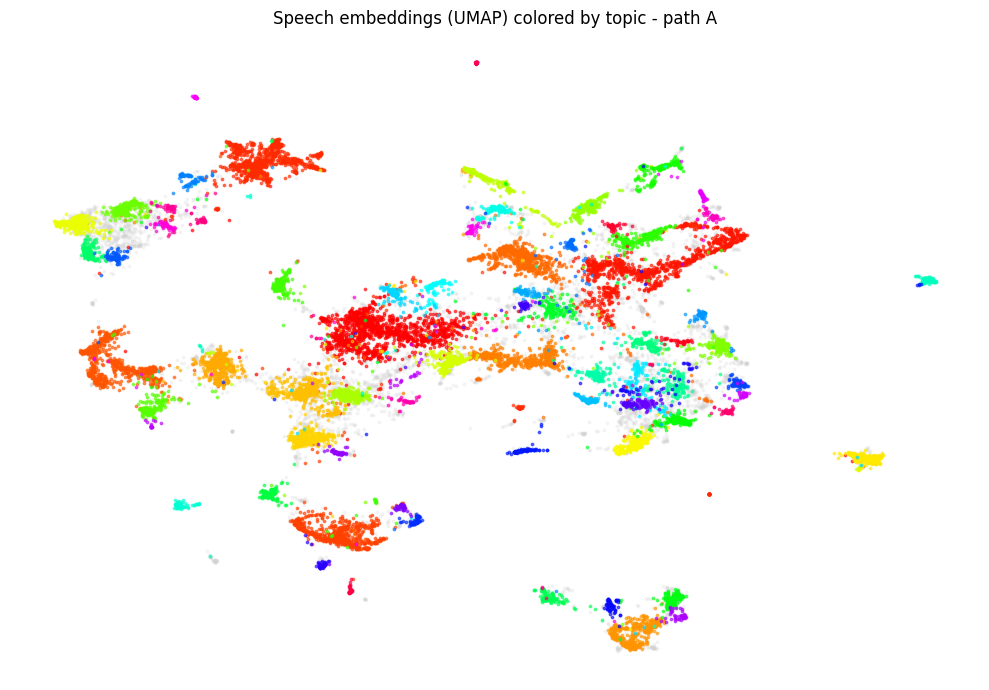

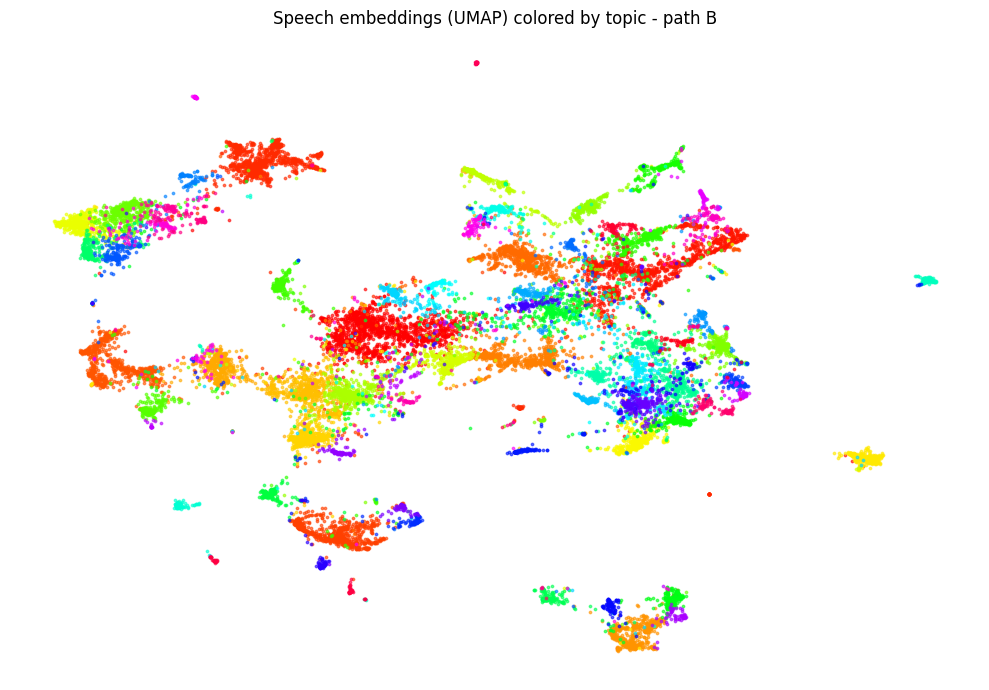

In [ ]:
def scatter_by_topic(topic_col, title):
    ts = df[topic_col].to_numpy()[idx]
    topics = [t for t in sorted(set(ts)) if t != -1]
    cmap = plt.get_cmap("hsv", len(topics))   # 72 distinguishable hues, one per topic
    fig, ax = plt.subplots(figsize=(10, 7))
    m1 = ts == -1                             # unassigned speeches drawn as grey background (path A only)
    if m1.any():
        ax.scatter(xy[m1, 0], xy[m1, 1], s=3, alpha=0.2, color="lightgrey", label="-1")
    for i, t in enumerate(topics):
        m = ts == t
        if m.any():
            ax.scatter(xy[m, 0], xy[m, 1], s=3, alpha=0.6, color=cmap(i))
    ax.axis("off"); ax.set_title(title)
    plt.tight_layout(); plt.show()

scatter_by_topic("topic_emb_raw",  "Speech embeddings (UMAP) colored by topic - path A")
scatter_by_topic("topic_emb_full", "Speech embeddings (UMAP) colored by topic - path B")

The same points coloured by **topic** break into clean, separated islands — the embedding space is organised by subject, not party. Path A shows the grey `-1` cloud (unassigned speeches); Path B colours it in.

## 6. Save the assignments

In [ ]:
# readable name per topic, taken from the label words
topic_names = {t: lab.split(": ", 1)[1] for t, lab in emb_labels.items()}   # strip the "12: " id prefix
topic_names[-1] = "unassigned"

out = (df[["politicianId", "party", "id", "topic_emb_raw", "topic_emb_full", "date"]]
       .rename(columns={"politicianId": "speaker_id", "id": "speech_id"}))
# both paths get a name column, so the later notebooks can filter on readable topics
out["topic_emb_raw_name"] = out["topic_emb_raw"].map(topic_names)
out["topic_emb_full_name"] = out["topic_emb_full"].map(topic_names)
out = out[["speaker_id", "party", "speech_id",
           "topic_emb_raw", "topic_emb_raw_name",
           "topic_emb_full", "topic_emb_full_name", "date"]]

out.to_csv("speech_topic_assignments.csv", index=False, encoding="utf-8")
print(f"wrote {len(out):,} rows to speech_topic_assignments.csv")
out.head()

wrote 82,447 rows to speech_topic_assignments.csv


,speaker_id,party,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name,date
0,11001434,SPD,604683,62,tanktourismus/markttransparenzstelle/benzinpreis,62,tanktourismus/markttransparenzstelle/benzinpreis,2000-01-19
1,11002754,CDU/CSU,604883,4,bafög-bericht/bologna-reform/studienfinanzierung,4,bafög-bericht/bologna-reform/studienfinanzierung,2000-01-20
2,11000431,SPD,604885,4,bafög-bericht/bologna-reform/studienfinanzierung,4,bafög-bericht/bologna-reform/studienfinanzierung,2000-01-20
3,11001180,FDP,604905,28,meerespolitik/wsv/pallas,28,meerespolitik/wsv/pallas,2000-01-20
4,11003216,CDU/CSU,605067,12,ptbs/wehrbeauftragter/penner,12,ptbs/wehrbeauftragter/penner,2000-01-21


Final deliverable: **`speech_topic_assignments.csv`**, one row per speech — speaker, party, speech id, both embedding topic paths (`topic_emb_raw` / `topic_emb_full`) with their topic **names**, and the date. This is what the trajectory notebook reads.